### **Exploration Data Analysis**

### Imports and project-path setup

In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:", PROJECT_ROOT)
print("Looking in:", RAW_DIR)

snapshots = sorted(
    RAW_DIR.glob("uci_credit_default_*.csv"),
    key=lambda path: path.stat().st_mtime,
    reverse=True
)

if not snapshots:
    raise FileNotFoundError(f"No UCI credit snapshots found in {RAW_DIR}")

DATA_PATH = snapshots[0]

#Load latest validated snapshot
df = pd.read_csv(DATA_PATH)

print(f"Dataset: {DATA_PATH.name}")
print(f"Shape: {df.shape}")

df.head()

Project root: c:\Users\guima\OneDrive\Documents\AI_project\banking_services_ai_assistant
Looking in: c:\Users\guima\OneDrive\Documents\AI_project\banking_services_ai_assistant\data\raw
Dataset: uci_credit_default_20260828_141517.csv
Shape: (30000, 25)


,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Initial data inspection 

In [ ]:
# Inspect the dataset structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   ID      30000 non-null  int64
 1   X1      30000 non-null  int64
 2   X2      30000 non-null  int64
 3   X3      30000 non-null  int64
 4   X4      30000 non-null  int64
 5   X5      30000 non-null  int64
 6   X6      30000 non-null  int64
 7   X7      30000 non-null  int64
 8   X8      30000 non-null  int64
 9   X9      30000 non-null  int64
 10  X10     30000 non-null  int64
 11  X11     30000 non-null  int64
 12  X12     30000 non-null  int64
 13  X13     30000 non-null  int64
 14  X14     30000 non-null  int64
 15  X15     30000 non-null  int64
 16  X16     30000 non-null  int64
 17  X17     30000 non-null  int64
 18  X18     30000 non-null  int64
 19  X19     30000 non-null  int64
 20  X20     30000 non-null  int64
 21  X21     30000 non-null  int64
 22  X22     30000 non-null  int64
 23  X23     30000 non-null

In [11]:
# Extract statistics 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X2,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
X3,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
X4,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
X7,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
X8,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
X9,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [12]:
# Count missing value and unique-values by variable
pd.DataFrame({
    "missing": df.isna().sum(),
    "unique_values": df.nunique()
})

,missing,unique_values
ID,0,30000
X1,0,81
X2,0,2
X3,0,7
X4,0,4
X5,0,56
X6,0,11
X7,0,11
X8,0,11
X9,0,11


### Key variable mapping

| Dataset Variable | Operational definition (Business value)                                              |
| ---------------- | ---------------------------------------------------- |
| `ID`             | Client identifier                                    |
| `X1`             | Credit limit / amount of given credit                |
| `X2`             | Sex                                                  |
| `X3`             | Education                                            |
| `X4`             | Marital status                                       |
| `X5`             | Age                                                  |
| `X6`–`X11`       | Repayment status for the previous six months         |
| `X12`–`X17`      | Bill statement amounts for the previous six months   |
| `X18`–`X23`      | Previous payment amounts for the previous six months |
| `Y`              | Default status: `1` = default, `0` = no default      |


### Inspect the target variable "Y - Default status" 

In [13]:
# Analyze the distribution of the target variable "Y".
df["Y"].value_counts(normalize=True).mul(100).round(2)

Y
0    77.88
1    22.12
Name: proportion, dtype: float64

In [19]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

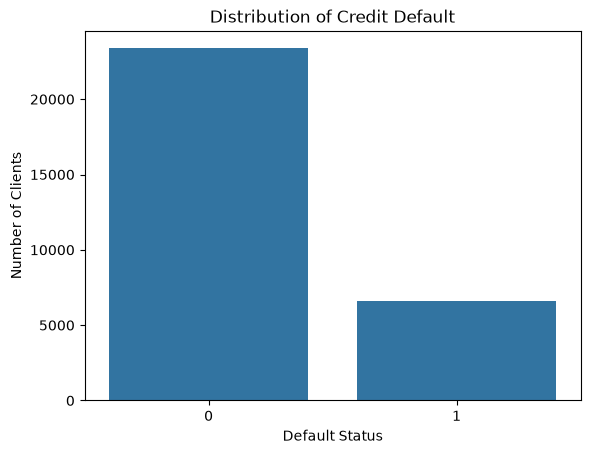

In [20]:
# Visualize the distribution of "Y"
sns.countplot(data=df, x="Y")
plt.title("Distribution of Credit Default")
plt.xlabel("Default Status")
plt.ylabel("Number of Clients")
plt.show()

##### The graph above shows that the variable Y, which is the default status, is skewed, with 77.88% of values equal to 0 and 22.12% of values equal to 1, respectively.

### Inspect numerical distribution

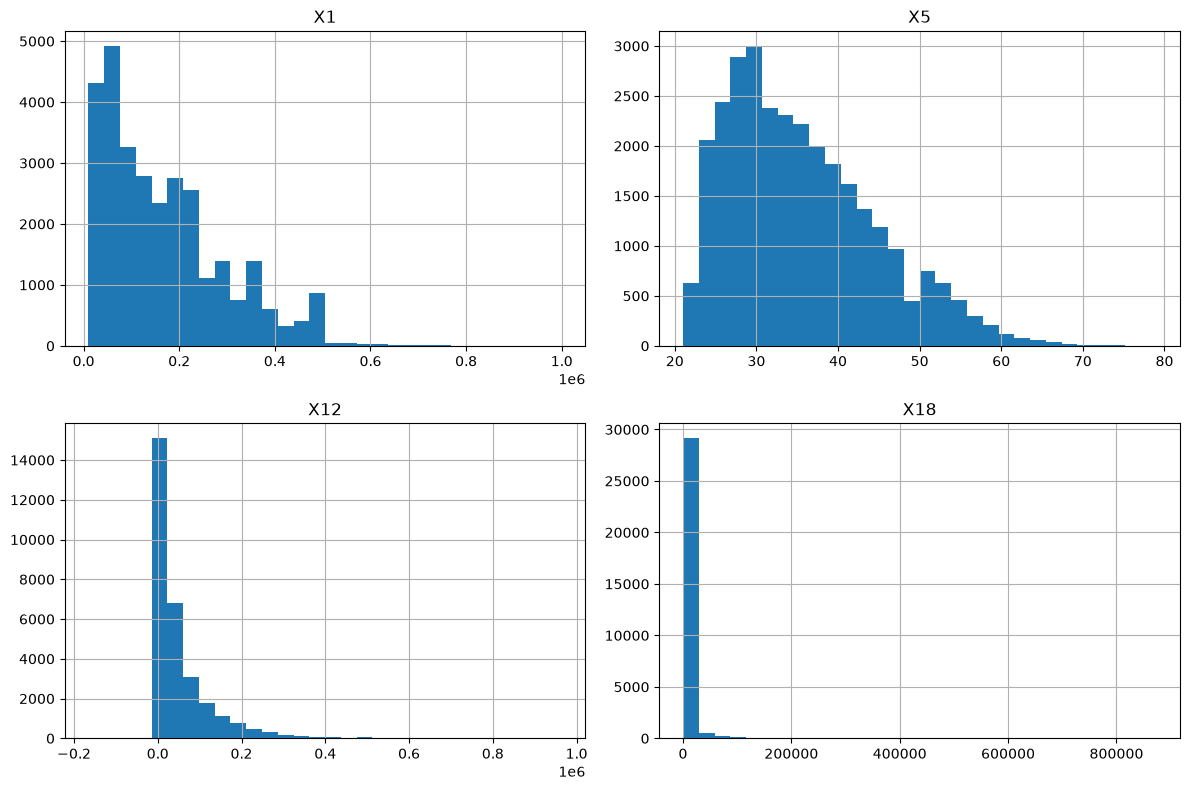

In [21]:
columns = [
    "X1",   # Credit limit
    "X5",   # Age
    "X12",  # Most recent bill amount
    "X18"   # Most recent payment amount
]

df[columns].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

* **All four variables are predominantly right-skewed (positively skewed).**

1. *X1 – Credit limit*: Right-skewed. Most clients have lower/moderate credit limits, with a long tail toward very high limits.

2. *X5 – Age*: Moderately right-skewed. Most clients are roughly 25–45, with the tail extending toward older ages.

3. *X12 – Latest bill amount*: Strongly right-skewed. Most observations are concentrated around lower bill amounts, with some very large values.

4. *X18 – Latest payment amount*: Extremely right-skewed. Most payments are relatively small, while a few observations are exceptionally large

### Correlation Analysis

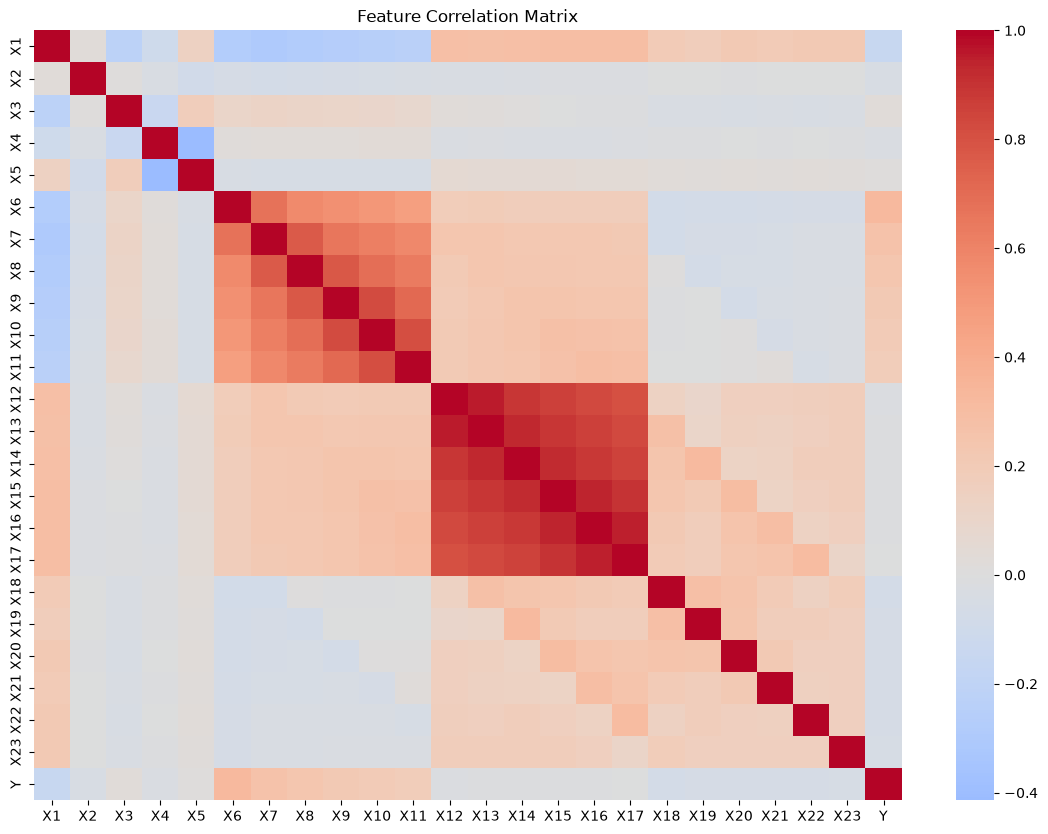

In [ ]:
# Plot the correlation matrix 
corr = df.drop(columns=["ID"]).corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# Display the correlation matrix
corr_matrix = df.drop(columns=["ID"]).corr(numeric_only=True)

corr_matrix.round(3)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
X1,1.000,0.025,-0.219,-0.108,0.145,-0.271,-0.296,-0.286,-0.267,-0.249,...,0.294,0.296,0.290,0.195,0.178,0.210,0.203,0.217,0.220,-0.154
X2,0.025,1.000,0.014,-0.031,-0.091,-0.058,-0.071,-0.066,-0.060,-0.055,...,-0.022,-0.017,-0.017,-0.000,-0.001,-0.009,-0.002,-0.002,-0.003,-0.040
X3,-0.219,0.014,1.000,-0.143,0.175,0.105,0.122,0.114,0.109,0.098,...,-0.000,-0.008,-0.009,-0.037,-0.030,-0.040,-0.038,-0.040,-0.037,0.028
X4,-0.108,-0.031,-0.143,1.000,-0.414,0.020,0.024,0.033,0.033,0.036,...,-0.023,-0.025,-0.021,-0.006,-0.008,-0.004,-0.013,-0.001,-0.007,-0.024
X5,0.145,-0.091,0.175,-0.414,1.000,-0.039,-0.050,-0.053,-0.050,-0.054,...,0.051,0.049,0.048,0.026,0.022,0.029,0.021,0.023,0.019,0.014
X6,-0.271,-0.058,0.105,0.020,-0.039,1.000,0.672,0.574,0.539,0.509,...,0.179,0.181,0.177,-0.079,-0.070,-0.071,-0.064,-0.058,-0.059,0.325
X7,-0.296,-0.071,0.122,0.024,-0.050,0.672,1.000,0.767,0.662,0.623,...,0.222,0.221,0.219,-0.081,-0.059,-0.056,-0.047,-0.037,-0.037,0.264
X8,-0.286,-0.066,0.114,0.033,-0.053,0.574,0.767,1.000,0.777,0.687,...,0.227,0.225,0.222,0.001,-0.067,-0.053,-0.046,-0.036,-0.036,0.235
X9,-0.267,-0.060,0.109,0.033,-0.050,0.539,0.662,0.777,1.000,0.820,...,0.246,0.243,0.239,-0.009,-0.002,-0.069,-0.043,-0.034,-0.027,0.217
X10,-0.249,-0.055,0.098,0.036,-0.054,0.509,0.623,0.687,0.820,1.000,...,0.272,0.270,0.263,-0.006,-0.003,0.009,-0.058,-0.033,-0.023,0.204


In [ ]:
# Rank the correlation of each response varible to the target variable "Y"
target_corr = (
    df.drop(columns=["ID"])
    .corr(numeric_only=True)["Y"]
    .drop("Y")
    .sort_values(ascending=False)
)

target_corr.round(3)

X6     0.325
X7     0.264
X8     0.235
X9     0.217
X10    0.204
X11    0.187
X3     0.028
X5     0.014
X17   -0.005
X16   -0.007
X15   -0.010
X14   -0.014
X13   -0.014
X12   -0.020
X4    -0.024
X2    -0.040
X23   -0.053
X22   -0.055
X20   -0.056
X21   -0.057
X19   -0.059
X18   -0.073
X1    -0.154
Name: Y, dtype: float64

### Correlation analysis summary

* The matrix reveals a few important patterns for our credit-risk model.

1. Repayment status (X6–X11) : Strong correlations among themselves, reaching about 0.82.It means a client's repayment behavior tends to persist across months. This also signals potential multicollinearity.

2. Bill amounts (X12–X17) :	Very strong correlations, approximately 0.80–0.95, meaning Monthly outstanding balances are highly related across consecutive months. This is our strongest multicollinearity concern.

3. Payment amounts (X18–X23): Mostly low-to-moderate correlations meaning payments vary more substantially from month to month than bill balances.

4. Demographics (X2–X5) : Generally weak relationships with most variables	Sex, education, marital status, and age appear relatively independent of financial behavior in linear terms.

5. Credit limit (X1): Moderate relationships with bill/payment variables and negative relationship with repayment delays, meaning Credit capacity is meaningfully connected to account behavior.

* relationship with target variable default (Y)

1. The strongest correlations with default are:

X6     +0.325   ← Most recent repayment status
X7     +0.264
X8     +0.235
X9     +0.217
X10    +0.204
X11    +0.187
X1     -0.154   ← Credit limit

This is a useful business signal: recent repayment behavior appears considerably more informative about default than demographic characteristics or raw account balances.

The declining correlation from X6 → X11 is also interesting. More recent repayment behavior (X6) has a stronger relationship with default than older repayment history (X11).

2. Variables with very weak linear relationships with default

For example:

X17   -0.005
X16   -0.007
X15   -0.010
X5    +0.014
X13   -0.014
X14   -0.014

However, we should not remove these variables simply because their Pearson correlation with Y is low. A low individual linear correlation does not mean a variable has no predictive value when combined with other features.

#### **Main EDA conclusion**

* **Data quality:** The dataset contains no missing or null values, providing a solid foundation for preprocessing and modeling.

* **Target imbalance:** The default variable (`Y`) is moderately imbalanced, with 77.88% non-default (`0`) and 22.12% default (`1`) observations. This imbalance should be considered during model training and evaluation.

* **Feature distributions:** Credit limit, age, latest bill amount, and latest payment amount show right-skewed distributions, indicating potential outliers and suggesting that scaling or transformation should be evaluated during preprocessing.

* **Strongest default indicators:** Repayment-status variables (`X6–X11`) show the strongest relationships with default. The most recent repayment status (`X6`) has the highest correlation with `Y` (0.325), and the relationship gradually decreases for older repayment periods.

* **Weak individual relationships:** Demographic characteristics, bill amounts, and several payment variables have relatively weak linear correlations with default. However, they should not be discarded solely based on Pearson correlation because they may provide predictive information when combined with other features.

* **Multicollinearity:** Strong correlations exist among repayment-history variables and particularly among bill amounts (`X12–X17`, approximately 0.80–0.95). This should be addressed during feature selection and Logistic Regression development.

**Overall:** The EDA suggests that repayment behavior is the strongest initial predictor of credit default, while target imbalance, skewed financial variables, and multicollinearity will be the main considerations during preprocessing and model development.


##### Feature Definition

In [25]:
# Categorize the variables between target and predictors

# Identifier
id_column = "ID"

# Target
target = "Y"

# Predictors
feature_columns = [
    column for column in df.columns
    if column not in [id_column, target]
]

X = df[feature_columns].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of predictors:", len(feature_columns))

X shape: (30000, 23)
y shape: (30000,)
Number of predictors: 23


In [26]:
# Classify the variables in continuous, ordinal and nominal variables

# Continuous numerical features
continuous_features = [
    "X1",              # Credit limit
    "X5",              # Age
    "X12", "X13", "X14", "X15", "X16", "X17",  # Bill amounts
    "X18", "X19", "X20", "X21", "X22", "X23"   # Payment amounts
]

# Nominal categorical features
categorical_features = [
    "X2",  # Sex
    "X3",  # Education
    "X4"   # Marital status
]

# Ordinal repayment-status features
repayment_features = [
    "X6", "X7", "X8", "X9", "X10", "X11"
]

# Validate our feature definition

defined_features = (
    continuous_features
    + categorical_features
    + repayment_features
)

print("Predictors in dataset:", len(feature_columns))
print("Predictors defined:", len(defined_features))

print(
    "Missing from definition:",
    set(feature_columns) - set(defined_features)
)

print(
    "Unexpected features:",
    set(defined_features) - set(feature_columns)
)

Predictors in dataset: 23
Predictors defined: 23
Missing from definition: set()
Unexpected features: set()


##### We confirm that 23 predictors existed in the dataset after being excluded "ID" and set "Y" as target variable.

### Data Quality Check

In [27]:
coded_features = categorical_features + repayment_features

for column in coded_features:
    print(f"\n--- {column} ---")
    print(df[column].value_counts().sort_index())


--- X2 ---
X2
1    11888
2    18112
Name: count, dtype: int64

--- X3 ---
X3
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

--- X4 ---
X4
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

--- X6 ---
X6
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

--- X7 ---
X7
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

--- X8 ---
X8
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

--- X9 ---
X9
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

--- X10 ---
X10
-2     4546
-1     5539
 

In [28]:
### Flag unexpected categories

expected_categories = {
    "X2": {1, 2},
    "X3": {1, 2, 3, 4},
    "X4": {1, 2, 3}
}

for column, valid_values in expected_categories.items():

    observed_values = set(df[column].unique())
    unexpected_values = observed_values - valid_values

    print(f"{column}")
    print(f"Observed: {sorted(observed_values)}")
    print(f"Unexpected: {sorted(unexpected_values)}")
    print()

X2
Observed: [np.int64(1), np.int64(2)]
Unexpected: []

X3
Observed: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Unexpected: [np.int64(0), np.int64(5), np.int64(6)]

X4
Observed: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Unexpected: [np.int64(0)]



In [29]:
# Check numerical range
df[continuous_features].agg(["min", "max"]).T

,min,max
X1,10000,1000000
X5,21,79
X12,-165580,964511
X13,-69777,983931
X14,-157264,1664089
X15,-170000,891586
X16,-81334,927171
X17,-339603,961664
X18,0,873552
X19,0,1684259


In [30]:
# Check the target variable "Y" value
print(df["Y"].value_counts().sort_index())

Y
0    23364
1     6636
Name: count, dtype: int64


### Data Quality Check decision

* X2                 We Keep these values
* X3: 0, 5, 6        We Group these values as Other/Unknown
* X4: 0              We Group 0 as Other/Unknown
* X6–X11             We keep Keep repayment codes
* X1, X5             We Keep these values
* X12–X17 negatives  We Keep the negative values for now
* X12–X23 extremes   To be investigated as outliers
* Y                  These values are aligned to the ones expected

### Outliers analysis

In [31]:
# Detect outliers using the IQR method

outlier_summary = []

for column in continuous_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outliers": len(outliers),
        "Outlier_Percentage": len(outliers) / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.round(2)

,Feature,Lower_Bound,Upper_Bound,Outliers,Outlier_Percentage
0,X1,-235000.00,525000.00,167,0.56
1,X5,8.50,60.50,272,0.91
2,X12,-91739.62,162389.38,2400,8.00
3,X13,-88547.50,155538.50,2395,7.98
4,X14,-83581.50,146412.50,2469,8.23
5,X15,-75942.12,132774.88,2622,8.74
6,X16,-70878.25,122831.75,2725,9.08
7,X17,-70657.38,121111.62,2693,8.98
8,X18,-5009.00,11015.00,2745,9.15
9,X19,-5417.50,11250.50,2714,9.05


##### Outlier Analysis — Conclusion

* Credit limit (X1) and age (X5) have few outliers: only 0.56% and 0.91%, respectively. Their observed ranges are plausible, so there is little justification for removing these observations.

* Bill amounts (X12–X17) have ~8–9% IQR outliers. The 99th percentiles are around 280K–350K, while some maxima approach or exceed 1M. This confirms strong right tails. Negative bill amounts should remain because they may represent legitimate credit balances or overpayments.

* Payment amounts (X18–X23) show the strongest extreme-value behavior, with approximately 9–10% classified as IQR outliers. For example, X19 has a median of only 2,009, a 99th percentile of about 76,651, but a maximum of 1,684,259. This is clear evidence of a very long right tail.

* The IQR method is aggressive for these financial variables. Flagging nearly 10% of observations does not mean 10% of the dataset is erroneous. Credit balances and payments naturally tend to have asymmetric distributions.

### Multicollinearity analysis

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_features = continuous_features + repayment_features

X_vif = df[vif_features].copy()

# Add intercept
X_vif = add_constant(X_vif)

vif_results = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Remove intercept from results
vif_results = (
    vif_results[vif_results["Feature"] != "const"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_results.round(2)

,Feature,VIF
0,X13,25.86
1,X16,24.99
2,X14,21.77
3,X15,20.35
4,X17,15.02
5,X12,14.02
6,X10,4.72
7,X9,4.29
8,X8,3.66
9,X11,3.26


##### Multicollinearity conclusion

* Severe multicollinearity exists among X12–X17, the six monthly bill-amount variables:

   * X13: 25.86
   * X16: 24.99
   * X14: 21.77
   * X15: 20.35
   * X17: 15.02
* X12: 14.02

All are well above the VIF > 10 threshold. This is consistent with their correlations of approximately 0.80–0.95.

Repayment variables X6–X11 are acceptable. Their VIF values range from 1.92 to 4.72. Although these variables are correlated, the multicollinearity is not severe enough to justify removing them, especially because EDA showed they contain our strongest default signal.

Credit limit, age and payment variables have low VIFs, mostly between 1 and 2.2, indicating little multicollinearity concern.

**Decision**

We wil not feed all six bill variables (X12–X17) directly into our Logistic Regression. They represent essentially repeated measurements of the same underlying financial behavior and create unnecessary redundancy.

A good approach for this project is to replace them later with a small number of engineered features, for example:

X12–X17 to Average Bill Balance or Recent Bill Balance or Bill Balance Trend

This preserves the financial information across six months while reducing dimensionality and multicollinearity—particularly appropriate for our goal of a lightweight, interpretable model.

### Splitting the dataset

In [34]:
from sklearn.model_selection import train_test_split

# Define predictors and target
X = df.drop(columns=["ID", "Y"])
y = df["Y"]

# 80% training / 20% final test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24000, 23)
X_test: (6000, 23)
y_train: (24000,)
y_test: (6000,)


### Class imbalance strategy

| Decision                       | Approach                                                                                                                    |
| ------------------------------ | --------------------------------------------------------------------------------------------------------------------------- |
| **Preserve class proportions** | Already handled through `stratify=y` during the train/test split.                                                           |
| **Baseline model**             | Train Logistic Regression first on the original training data.                                                              |
| **Class weighting**            | Compare with `class_weight="balanced"` if recall for defaults is too low.                                                   |
| **Oversampling / SMOTE**       | Do not use initially; it adds complexity and synthetic observations.                                                    |
| **Primary metrics**            | Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix rather than Accuracy alone.                                      |
| **Business priority**          | Pay particular attention to Recall for class `1`, because missing a genuinely risky borrower can create financial loss. |


In [ ]:
# Create the baseline preprocessing and Logistic Regression pipeline.

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])


# Fit the logistic regression model using X_train_eng and y_train
baseline_pipeline.fit(X_train_eng, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['X1','X2','X3',...,'X23','AVG_BILL','BILL_TREND']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('credit_capacity', ...), ('customer_age', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthroug

### Baseline model evaluation

In [72]:
# Generate predictions
y_pred = baseline_pipeline.predict(X_test_eng)

y_proba = baseline_pipeline.predict_proba(X_test_eng)[:, 1]

In [ ]:
# Calculate evaluation matrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.3f}")

Accuracy: 0.806
Precision: 0.658
Recall: 0.254
F1-score: 0.367
ROC-AUC: 0.737


In [73]:
# Generate the classification report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Default", "Default"]
    )
)

              precision    recall  f1-score   support

  No Default       0.82      0.96      0.89      4673
     Default       0.66      0.25      0.37      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.61      0.63      6000
weighted avg       0.78      0.81      0.77      6000



In [ ]:
# Generate the confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4498  175]
 [ 990  337]]


### Experiment 2 : Balanced Logistic Regression

In [50]:
# Create the preprocessor

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

# Train the model
balanced_pipeline.fit(X_train_eng, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['X1','X2','X3',...,'X23','AVG_BILL','BILL_TREND']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standard', ...), ('payments', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [51]:
# Generate predictions
y_pred_balanced = balanced_pipeline.predict(X_test_eng)

y_proba_balanced = balanced_pipeline.predict_proba(
    X_test_eng
)[:, 1]

In [52]:
# Evaluate the balanced logistic regression model
balanced_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_balanced),
    "Precision": precision_score(y_test, y_pred_balanced),
    "Recall": recall_score(y_test, y_pred_balanced),
    "F1-score": f1_score(y_test, y_pred_balanced),
    "ROC-AUC": roc_auc_score(y_test, y_proba_balanced)
}

for metric, value in balanced_metrics.items():
    print(f"{metric}: {value:.3f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=["No Default", "Default"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.731
Precision: 0.425
Recall: 0.613
F1-score: 0.502
ROC-AUC: 0.741

Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.76      0.82      4673
     Default       0.42      0.61      0.50      1327

    accuracy                           0.73      6000
   macro avg       0.65      0.69      0.66      6000
weighted avg       0.77      0.73      0.75      6000

Confusion Matrix:
[[3573 1100]
 [ 514  813]]


### Experiement 3: Lightweight cross-validation tuning

In [40]:
# Implement the cross-validation method to tune the model
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

param_grid = {
    "classifier__C": [0.1, 1.0, 10.0],
    "classifier__class_weight": [None, "balanced"]
}

### Grid search implementation

In [41]:
# Fit the model 
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train_eng, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1.0, ...], 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_sele

In [44]:
# Derive the best model
best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1:")
print(round(grid_search.best_score_, 3))
print(best_model)

Best parameters:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}

Best cross-validation F1:
0.516
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('standard', StandardScaler(),
                                                  ['X1', 'X5', 'X12',
                                                   'AVG_BILL', 'BILL_TREND']),
                                                 ('payments',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['X18', 'X19', 'X20', 'X21',
     

### Threshold analysis

In [45]:
# Decision threshold tuning
from sklearn.model_selection import cross_val_predict

y_train_proba_cv = cross_val_predict(
    best_model,
    X_train_eng,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]



In [46]:
# Evaluate several theresholds
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_train_proba_cv >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train, y_pred_threshold),
        "Recall": recall_score(y_train, y_pred_threshold),
        "F1": f1_score(y_train, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(3)

,Threshold,Precision,Recall,F1
0,0.30,0.259,0.911,0.403
1,0.35,0.283,0.857,0.425
2,0.40,0.323,0.785,0.458
3,0.45,0.377,0.698,0.490
4,0.50,0.436,0.631,0.516
5,0.55,0.481,0.575,0.524
6,0.60,0.520,0.523,0.521
7,0.65,0.554,0.463,0.504
8,0.70,0.593,0.385,0.467


##### *The Threshold with value 0.55 provide the best trade-off Precision-Recall and the highest F1 value 0.524*

### Final model evaluation

In [47]:
# Generate probabilities
y_test_proba_final = best_model.predict_proba(X_test_eng)[:, 1]

# Apply our selected threshold
final_threshold = 0.55

y_test_pred_final = (
    y_test_proba_final >= final_threshold
).astype(int)

# Calculate final metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred_final),
    "Precision": precision_score(y_test, y_test_pred_final),
    "Recall": recall_score(y_test, y_test_pred_final),
    "F1-score": f1_score(y_test, y_test_pred_final),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_final)
}

for metric, value in final_metrics.items():
    print(f"{metric}: {value:.3f}")

Accuracy: 0.764
Precision: 0.472
Recall: 0.561
F1-score: 0.513
ROC-AUC: 0.741


In [48]:
# Classification report
print(
    classification_report(
        y_test,
        y_test_pred_final,
        target_names=["No Default", "Default"]
    )
)

              precision    recall  f1-score   support

  No Default       0.87      0.82      0.84      4673
     Default       0.47      0.56      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000



In [49]:
# Confusion matrix
final_cm = confusion_matrix(
    y_test,
    y_test_pred_final
)

print(final_cm)

[[3840  833]
 [ 582  745]]


### **Conclusion**

The tuned model provides a materially better credit-risk trade-off than our original baseline. The baseline detected only 25.4% of defaulters, whereas the final model detects 56.1%, while maintaining moderate discrimination (ROC-AUC = 0.741). The remaining false-negative and false-positive rates should be clearly communicated as model limitations.

### Import transformations "credit_transformers.py" 

**Transformation strategy**

| Feature group      | Variables  | Transformation                                             |
| ------------------ | ---------- | ---------------------------------------------------------- |
| Credit limit & age | `X1`, `X5` | Standard scaling                                           |
| Bill amounts       | `X12–X17`  | Engineer features to address multicollinearity, then scale |
| Payment amounts    | `X18–X23`  | `log1p` transformation + scaling                           |
| Categorical        | `X2–X4`    | Clean undocumented categories + One-Hot Encoding           |
| Repayment status   | `X6–X11`   | Keep their ordinal structure; scale                        |
| Target             | `Y`        | No transformation                                          |


In [57]:
# Import sys so we can control where Python searches for project modules.
import sys

# Import Path for reliable file-system path handling.
from pathlib import Path


# Select the parent directory for the project root.
PROJECT_ROOT = Path.cwd().parent


# Add the project root to Python's module search path.
# This allows Python to find folders such as /ml.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import reusable business transformation functions from the project preprocessing module.
from ml.preprocessing.credit_transformers import (
    clean_categories,
    engineer_bill_features
)

### Apply transformations

In [58]:
# Apply the reusable category-cleaning rules to the training dataset.

X_train_business = clean_categories(X_train)

# Engineer the business-relevant bill features.
X_train_business = engineer_bill_features(
    X_train_business
)

# Apply the exact same transformations to the test dataset.
X_test_business = clean_categories(X_test)

X_test_business = engineer_bill_features(
    X_test_business
)

# Verify the transformation results.
print("Original training shape:", X_train.shape)
print("Transformed training shape:", X_train_business.shape)

print("\nTransformed columns:")
print(X_train_business.columns.tolist())

Original training shape: (24000, 23)
Transformed training shape: (24000, 20)

Transformed columns:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'AVG_BILL', 'BILL_TREND']


### Define the variables from a business standpoint

In [59]:
# Credit capacity
credit_capacity_features = [
    "X1"   # Amount of credit granted / credit limit
]

# Customer profile
customer_profile_features = [
    "X2",  # Sex
    "X3",  # Education
    "X4",  # Marital status
    "X5"   # Age
]

# Repayment behavior over the last six months
repayment_behavior_features = [
    "X6", "X7", "X8",
    "X9", "X10", "X11"
]

# Credit exposure / outstanding balances
credit_exposure_features = [
    "X12",       # Most recent bill balance
    "AVG_BILL",  # Average six-month bill balance
    "BILL_TREND" # Change in balance over the observed period
]

# Historical payment behavior
payment_behavior_features = [
    "X18", "X19", "X20",
    "X21", "X22", "X23"
]

### Define the features group

In [60]:
# MODEL FEATURE GROUPS — BUSINESS DEFINITIONS

# 1. CREDIT CAPACITY
# Represents the amount of credit available to the client.
credit_capacity_features = [
    "X1"  # Credit limit
]


# 2. CUSTOMER DEMOGRAPHIC PROFILE
# Describes basic characteristics of the client.

# X2, X3 and X4 are categorical and will therefore be processed separately from age.
customer_categorical_features = [
    "X2",  # Sex
    "X3",  # Education level
    "X4"   # Marital status
]

customer_age_feature = [
    "X5"   # Age
]


# 3. REPAYMENT BEHAVIOR
# Represents the client's repayment status over six months.
# These variables provide important information about delayed or missed payments.
repayment_behavior_features = [
    "X6",
    "X7",
    "X8",
    "X9",
    "X10",
    "X11"
]


# 4. CREDIT EXPOSURE
# Summarizes how much debt the client is carrying.
# X12 = Most recent bill balance
# AVG_BILL = Average balance over six months
# BILL_TREND = Change in balance over the observed period
credit_exposure_features = [
    "X12",
    "AVG_BILL",
    "BILL_TREND"
]


# 5. PAYMENT BEHAVIOR
# Represents actual amounts paid by the client during the six-month observation period.
payment_behavior_features = [
    "X18",
    "X19",
    "X20",
    "X21",
    "X22",
    "X23"
]

### Define the payment transformation

In [61]:
# Required libraries for preprocessing.
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer
)


# PAYMENT-BEHAVIOR PIPELINE

# Step 1:
# log1p reduces the strong right-skewness of payment amounts.

# np.log1p(x) calculates log(1 + x), which allows payment values equal to zero to be transformed safely.

# Step 2:
# StandardScaler places the transformed payment variables on comparable numerical scales for Logistic Regression.

payment_pipeline = Pipeline([
    
    (
        "log_transform",
        FunctionTransformer(
            np.log1p,
            feature_names_out="one-to-one"
        )
    ),
    
    (
        "scaler",
        StandardScaler()
    )
])

### Build the column transformer

In [62]:
from sklearn.compose import ColumnTransformer

# MODEL PREPROCESSOR

# Each business feature group receives the transformation appropriate to its statistical characteristics and meaning.

preprocessor = ColumnTransformer(
    transformers=[

        # Credit capacity:
        # Standardize the client's credit limit.
        (
            "credit_capacity",
            StandardScaler(),
            credit_capacity_features
        ),

        # Customer age:
        # Standardize age as a continuous numerical variable.
        (
            "customer_age",
            StandardScaler(),
            customer_age_feature
        ),

        # Customer categorical characteristics:
        # Convert categories into binary indicator variables.
        
        # handle_unknown="ignore" allows the deployed model to handle a category not observed during training without crashing.
        (
            "customer_profile",
            OneHotEncoder(handle_unknown="ignore"),
            customer_categorical_features
        ),

        # Repayment behavior: Standardize the six repayment-status variables.
        (
            "repayment_behavior",
            StandardScaler(),
            repayment_behavior_features
        ),

        # Credit exposure: Standardize current balance, average balance, and the balance trend.
        (
            "credit_exposure",
            StandardScaler(),
            credit_exposure_features
        ),

        # Payment behavior: First reduce skewness and then standardize.
        (
            "payment_behavior",
            payment_pipeline,
            payment_behavior_features
        )
    ]
)

### Build the complete deployment pipeline

In [63]:
# COMPLETE DEPLOYMENT PIPELINE

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression


# The deployment pipeline combines:
# 1. Business category cleaning
# 2. Business feature engineering
# 3. Statistical preprocessing
# 4. Final tuned Logistic Regression model

# This means the future web application can send raw client information directly into this pipeline.

deployment_pipeline = Pipeline([

    # --------------------------------------------------------
    # STEP 1 — Clean categorical business variables
    # --------------------------------------------------------
    
    # Uses the reusable clean_categories() function imported from ml/preprocessing/credit_transformers.py.
    (
        "category_cleaning",
        FunctionTransformer(
            clean_categories,
            validate=False
        )
    ),

    # --------------------------------------------------------
    # STEP 2 — Engineer credit-exposure features
    # --------------------------------------------------------
    
    # Creates:
    #   AVG_BILL
    #   BILL_TREND
    # and removes redundant historical bill variables X13-X17.
    (
        "feature_engineering",
        FunctionTransformer(
            engineer_bill_features,
            validate=False
        )
    ),

    # --------------------------------------------------------
    # STEP 3 — Apply statistical preprocessing
    # --------------------------------------------------------
    
    # Includes:
    #   - StandardScaler
    #   - OneHotEncoder
    #   - log1p transformation for payments according to the business feature groups defined earlier.
    (
        "preprocessor",
        preprocessor
    ),

    # --------------------------------------------------------
    # STEP 4 — Final classification model
    # --------------------------------------------------------
    #
    # C = 0.1:
    # Best regularization strength identified by GridSearchCV.
    # class_weight = "balanced":
    # Gives additional importance to the minority default class.
    # max_iter = 1000:
    # Allows sufficient iterations for model convergence.
    (
        "classifier",
        LogisticRegression(
            C=0.1,
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

### Train the complete pipeline

In [64]:
# Train the complete deployment pipeline using the original
# 23 raw client features.

deployment_pipeline.fit(
    X_train,
    y_train
)

print("Deployment pipeline trained successfully.")

Deployment pipeline trained successfully.


### Serialize and save classification Model V1.

In [ ]:
# ============================================================
# SAVE CLASSIFICATION MODEL V1
# ============================================================
# Purpose:
# Package the complete deployment pipeline together with the business threshold and model metadata required by
# the future API and web application.

from pathlib import Path
from datetime import datetime
import joblib


# Define the folder where deployment artifacts will be stored.
MODEL_DIR = PROJECT_ROOT / "models" / "artifacts"

# Create the folder if it does not already exist.
MODEL_DIR.mkdir(parents=True, exist_ok=True)


# Build the deployment bundle.
# This stores not only the trained model pipeline, but also the business information required to interpret predictions.
classification_bundle = {

    # Complete end-to-end pipeline:
    # raw client data -> cleaning -> feature engineering -> preprocessing -> Logistic Regression.
    "pipeline": deployment_pipeline,

    # Business threshold used to convert PD into a class.
    "threshold": 0.55,

    # Internal version of the deployed classification model.
    "model_version": "1.0.0",

    # Business/model identifier.
    "model_name": "credit_default_classifier",

    # Algorithm selected after model comparison and tuning.
    "algorithm": "Balanced Logistic Regression",

    # Final hyperparameters selected through GridSearchCV.
    "parameters": {
        "C": 0.1,
        "class_weight": "balanced"
    },

    # Original raw input variables expected by the model.
    "input_features": list(X_train.columns),

    # Business target.
    "target": "Y",

    # Final test metrics for traceability.
    "test_metrics": {
        "accuracy": 0.764,
        "precision": 0.472,
        "recall": 0.561,
        "f1_score": 0.513,
        "roc_auc": 0.741
    },

    # Timestamp indicating when this artifact was created.
    "created_at": datetime.now().isoformat()
}


# Define the output file.
MODEL_PATH = MODEL_DIR / "credit_risk_classifier_v1.joblib"


# Serialize the complete bundle.
joblib.dump(
    classification_bundle,
    MODEL_PATH
)


print("Classification Model v1 saved successfully.")
print(f"Artifact location: {MODEL_PATH}")

Classification Model v1 saved successfully.
Artifact location: c:\Users\guima\OneDrive\Documents\AI_project\banking_services_ai_assistant\models\artifacts\credit_risk_classifier_v1.joblib


### Reload and test the saved model

In [68]:
# ============================================================
# RELOAD TEST — CLASSIFICATION MODEL V1
# ============================================================
# Purpose:
# Verify that the serialized model artifact can be loaded
# independently and used to predict credit-default risk
# without retraining the model.

import joblib


# Load the complete deployment bundle from disk.
loaded_bundle = joblib.load(
    MODEL_DIR / "credit_risk_classifier_v1.joblib"
)


# Extract the trained end-to-end pipeline.
loaded_model = loaded_bundle["pipeline"]

# Extract the business decision threshold.
loaded_threshold = loaded_bundle["threshold"]


# Select one raw client from the test dataset.
# IMPORTANT:
# We use raw X_test because the saved pipeline performs
# cleaning, feature engineering and preprocessing internally.
sample_client = X_test.iloc[[0]]


# Generate the client's Probability of Default (PD).
sample_pd = loaded_model.predict_proba(
    sample_client
)[0, 1]


# Apply the saved business threshold.
#
# PD >= threshold -> Default (1)
# PD < threshold  -> No Default (0)
sample_prediction = int(
    sample_pd >= loaded_threshold
)


# Display model and prediction information.
print("Model version:", loaded_bundle["model_version"])
print("Algorithm:", loaded_bundle["algorithm"])
print("Threshold:", loaded_threshold)

print("\nProbability of Default:", round(sample_pd, 3))
print("Predicted Class:", sample_prediction)

Model version: 1.0.0
Algorithm: Balanced Logistic Regression
Threshold: 0.55

Probability of Default: 0.326
Predicted Class: 0
